Develop Test and Train data for 2B tokens initial development
model. Final Structure: 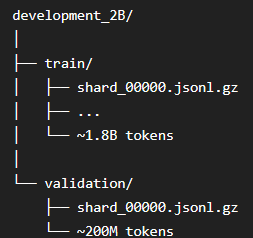

In [10]:
from google.colab import drive
import os
import shutil # Import shutil for rmtree

try:
  drive.flush_and_unmount()
except ValueError:
  # Drive was not mounted, safe to ignore
  pass

# Ensure the mount point is empty by recursively removing it if it exists
if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

# Create the directory before mounting
os.makedirs("/content/drive", exist_ok=True)

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [11]:
#Config cell
from pathlib import Path
import gzip
import json
import os
import shutil
from collections import defaultdict

# ============================================================
# PATHS
# ============================================================

CORPUS_ROOT = Path("/content/drive/MyDrive/SLM_Biomed")

SOURCE_TRAIN = CORPUS_ROOT / "train"

DEV_ROOT = CORPUS_ROOT / "development_2B"
DEV_TRAIN = DEV_ROOT / "train"
DEV_VAL = DEV_ROOT / "validation"

DEV_TRAIN.mkdir(parents=True, exist_ok=True)
DEV_VAL.mkdir(parents=True, exist_ok=True)

# ============================================================
# TARGETS
# ============================================================

TARGET_TOTAL = 2_000_000_000

# Recommended split
TARGET_TRAIN = 1_800_000_000
TARGET_VAL   = 200_000_000

print("Source:", SOURCE_TRAIN)
print("Development:", DEV_ROOT)
print(f"Train target: {TARGET_TRAIN:,} tokens")
print(f"Validation target: {TARGET_VAL:,} tokens")

Source: /content/drive/MyDrive/SLM_Biomed/train
Development: /content/drive/MyDrive/SLM_Biomed/development_2B
Train target: 1,800,000,000 tokens
Validation target: 200,000,000 tokens


### Verify the file path

After mounting Google Drive, you can verify the existence of the file in the specified `SOURCE_TRAIN` directory by running a command like this in a new cell:

```python
!ls -l {SOURCE_TRAIN}
```

This will list the contents of the directory, and you should see your `shard_00000.jsonl.gz` file there.

In [12]:
#First pass: calculate article sizes
import time

article_tokens = defaultdict(int)
total_tokens = 0
total_records = 0

train_files = sorted(SOURCE_TRAIN.glob("shard_*.jsonl.gz"))

print(f"Found {len(train_files)} source shards")

start = time.time()

for shard_idx, path in enumerate(train_files):

    shard_tokens = 0
    shard_records = 0

    with gzip.open(path, "rt", encoding="utf-8") as f:

        for line in f:

            rec = json.loads(line)

            article_id = rec["article_id"]
            tokens = int(rec["token_count"])

            article_tokens[article_id] += tokens

            total_tokens += tokens
            total_records += 1

            shard_tokens += tokens
            shard_records += 1

    elapsed = time.time() - start

    print(
        f"[{shard_idx+1:02d}/{len(train_files)}] "
        f"{path.name}: "
        f"{shard_tokens:,} tokens | "
        f"{shard_records:,} records | "
        f"Total: {total_tokens/1e9:.3f}B | "
        f"{elapsed/60:.1f} min"
    )

print("\nDONE")
print(f"Total records : {total_records:,}")
print(f"Total tokens  : {total_tokens:,}")
print(f"Articles      : {len(article_tokens):,}")

Found 18 source shards
[01/18] shard_00000.jsonl.gz: 500,000,080 tokens | 2,293,407 records | Total: 0.500B | 1.0 min
[02/18] shard_00001.jsonl.gz: 250,000,277 tokens | 1,144,497 records | Total: 0.750B | 1.5 min
[03/18] shard_00002.jsonl.gz: 250,000,044 tokens | 1,125,860 records | Total: 1.000B | 1.9 min
[04/18] shard_00003.jsonl.gz: 250,000,137 tokens | 1,079,890 records | Total: 1.250B | 2.4 min
[05/18] shard_00004.jsonl.gz: 250,000,077 tokens | 1,083,629 records | Total: 1.500B | 2.9 min
[06/18] shard_00005.jsonl.gz: 250,000,226 tokens | 1,082,678 records | Total: 1.750B | 3.4 min
[07/18] shard_00006.jsonl.gz: 250,000,115 tokens | 1,082,922 records | Total: 2.000B | 3.9 min
[08/18] shard_00007.jsonl.gz: 250,000,378 tokens | 1,082,135 records | Total: 2.250B | 4.4 min
[09/18] shard_00008.jsonl.gz: 250,000,120 tokens | 1,081,511 records | Total: 2.500B | 4.9 min
[10/18] shard_00009.jsonl.gz: 250,000,397 tokens | 1,096,152 records | Total: 2.750B | 5.4 min
[11/18] shard_00010.jsonl.g

#Select articles for development train and validation
The procedure is:

deterministically shuffle article IDs;
select complete articles for development training until ~1.8B;
continue selecting different complete articles for validation until ~200M.

In [13]:
import hashlib

def stable_hash(article_id):
    """
    Deterministic hash.
    Same article_id always gets the same ordering.
    """
    return int(
        hashlib.sha256(article_id.encode("utf-8")).hexdigest(),
        16
    )

article_ids = list(article_tokens.keys())

# Deterministic pseudo-random ordering
article_ids.sort(key=stable_hash)

selected_train = set()
selected_val = set()

train_tokens = 0
val_tokens = 0

# ------------------------------------------------------------
# Select training articles
# ------------------------------------------------------------

for article_id in article_ids:

    t = article_tokens[article_id]

    if train_tokens + t <= TARGET_TRAIN:
        selected_train.add(article_id)
        train_tokens += t

    if train_tokens >= TARGET_TRAIN:
        break

# ------------------------------------------------------------
# Select validation articles from remaining articles
# ------------------------------------------------------------

for article_id in article_ids:

    if article_id in selected_train:
        continue

    t = article_tokens[article_id]

    if val_tokens + t <= TARGET_VAL:
        selected_val.add(article_id)
        val_tokens += t

    if val_tokens >= TARGET_VAL:
        break

print("Development split created")
print()
print(f"Train articles      : {len(selected_train):,}")
print(f"Train tokens        : {train_tokens:,}")
print(f"Train tokens (B)    : {train_tokens/1e9:.4f}")
print()
print(f"Validation articles : {len(selected_val):,}")
print(f"Validation tokens   : {val_tokens:,}")
print(f"Validation tokens B : {val_tokens/1e9:.4f}")
print()
print(f"Total development   : {(train_tokens+val_tokens)/1e9:.4f}B")

Development split created

Train articles      : 330,290
Train tokens        : 1,799,999,987
Train tokens (B)    : 1.8000

Validation articles : 36,841
Validation tokens   : 199,999,966
Validation tokens B : 0.2000

Total development   : 2.0000B


In [14]:
#Verify there is no article overlap
overlap = selected_train & selected_val

print("Train articles:", len(selected_train))
print("Validation articles:", len(selected_val))
print("Overlap:", len(overlap))

assert len(overlap) == 0, "ERROR: article leakage detected!"

print("✓ No article overlap")

Train articles: 330290
Validation articles: 36841
Overlap: 0
✓ No article overlap


Write development train/validation shards

We can now scan the original corpus again and write selected articles.

I'm using 250M-token target shards, matching the approach you already used for your main corpus.

In [15]:
def write_split(
    selected_articles,
    output_dir,
    split_name,
    shard_target_tokens=250_000_000
):

    output_dir.mkdir(parents=True, exist_ok=True)

    shard_idx = 0
    shard_tokens = 0
    shard_records = 0

    total_tokens_written = 0
    total_records_written = 0
    articles_written = set()

    out_path = output_dir / f"shard_{shard_idx:05d}.jsonl.gz"
    out_file = gzip.open(out_path, "wt", encoding="utf-8")

    start = time.time()

    try:

        for src_idx, src_path in enumerate(train_files):

            print(
                f"[{split_name}] "
                f"Scanning {src_path.name}"
            )

            with gzip.open(src_path, "rt", encoding="utf-8") as f:

                for line in f:

                    rec = json.loads(line)

                    article_id = rec["article_id"]

                    if article_id not in selected_articles:
                        continue

                    # Write record
                    out_file.write(json.dumps(
                        rec,
                        ensure_ascii=False
                    ) + "\n")

                    tokens = int(rec["token_count"])

                    shard_tokens += tokens
                    shard_records += 1

                    total_tokens_written += tokens
                    total_records_written += 1

                    articles_written.add(article_id)

                    # Start a new shard after target
                    if shard_tokens >= shard_target_tokens:

                        out_file.close()

                        print(
                            f"  Wrote {out_path.name}: "
                            f"{shard_tokens:,} tokens, "
                            f"{shard_records:,} records"
                        )

                        shard_idx += 1
                        shard_tokens = 0
                        shard_records = 0

                        out_path = (
                            output_dir /
                            f"shard_{shard_idx:05d}.jsonl.gz"
                        )

                        out_file = gzip.open(
                            out_path,
                            "wt",
                            encoding="utf-8"
                        )

    finally:

        out_file.close()

    # Remove empty final shard
    if out_path.exists() and out_path.stat().st_size == 0:
        out_path.unlink()

    elapsed = time.time() - start

    print()
    print(f"========== {split_name.upper()} COMPLETE ==========")
    print(f"Articles : {len(articles_written):,}")
    print(f"Records  : {total_records_written:,}")
    print(f"Tokens   : {total_tokens_written:,}")
    print(f"Tokens B : {total_tokens_written/1e9:.4f}")
    print(f"Time     : {elapsed/60:.1f} min")

    return total_tokens_written

In [ ]:
#Create the two datasets
train_written = write_split(
    selected_articles=selected_train,
    output_dir=DEV_TRAIN,
    split_name="development train"
)

val_written = write_split(
    selected_articles=selected_val,
    output_dir=DEV_VAL,
    split_name="development validation"
)

[development train] Scanning shard_00000.jsonl.gz
[development train] Scanning shard_00001.jsonl.gz
  Wrote shard_00000.jsonl.gz: 250,000,041 tokens, 1,143,030 records
[development train] Scanning shard_00002.jsonl.gz


Final leakage verification

In [ ]:
print("Checking article overlap...")

train_articles = set()
val_articles = set()

for path in DEV_TRAIN.glob("shard_*.jsonl.gz"):

    with gzip.open(path, "rt", encoding="utf-8") as f:

        for line in f:
            rec = json.loads(line)
            train_articles.add(rec["article_id"])


for path in DEV_VAL.glob("shard_*.jsonl.gz"):

    with gzip.open(path, "rt", encoding="utf-8") as f:

        for line in f:
            rec = json.loads(line)
            val_articles.add(rec["article_id"])


overlap = train_articles & val_articles

print(f"Train articles      : {len(train_articles):,}")
print(f"Validation articles : {len(val_articles):,}")
print(f"Overlap             : {len(overlap):,}")

assert len(overlap) == 0

print("✓ DEVELOPMENT SPLIT PASSED")
print("✓ No train/validation article leakage")